# 03 — Neural Equivalent Magnetic Circuit

**Project:** NeuRelux. Compares three ways to predict flux density from current, air gap, and temperature: ATLAS's assumed linear circuit, a black-box MLP, and a physics-encoded neural circuit that only replaces the uncertain permeability term.

## 1. Motivation

ATLAS's assumed model (`PLAN.md` §1) uses a linear or piecewise-linear reluctance circuit — a reasonable approximation near the calibration point, but one that cannot represent saturation, and has no principled way to extrapolate to unseen current, air gap, or temperature. This notebook tests whether replacing *only* the uncertain material term (not the whole circuit) gives better extrapolation than either the original linear model or a full black-box replacement.

## 2. Physical problem

A coil of $N$ turns carrying current $I$ drives magnetic flux through a series magnetic circuit: the core (steel, permeability $\mu_r(B,T)$, saturating as $B$ grows) and an air gap $g$ (constant permeability $\mu_0$, by definition — air doesn't saturate). The air-gap reluctance is *exact geometry*; the core's reluctance is the only genuinely uncertain quantity.

## 3. Governing equations

$$
\Theta = N I, \qquad \Theta = H_{\text{core}}(B,T)\, l_{\text{core}} + \frac{B}{\mu_0} g, \qquad H_{\text{core}}(B,T) = \frac{B}{\mu_0\,\mu_r(B,T)}
$$

This notebook's synthetic "true" system uses a Froehlich-style saturating permeability (illustrative, steel-range parameters — not measured ATLAS data, see `PLAN.md` §0):

$$
\mu_r(B,T) = \frac{\mu_{r0}(T)}{1 + \left(B/B_{\text{sat}}(T)\right)^n}
$$

Given $(\Theta, g, T)$, $B$ is the root of $\Theta - H_{\text{core}}(B,T)\,l_{\text{core}} - (B/\mu_0)g = 0$ — solved here by fixed-point (successive-substitution) iteration, not a black-box root finder: substitute the current $B$ estimate's permeability into the linear form and repeat (`src/atlas_physics/magnetic_circuit.py::solve_B`), the same fixed-iteration-count philosophy as Notebook 01's explicit Euler and Notebook 02's explicit-stepped Jiles-Atherton.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** none of the three models use engineered features beyond $(I, g, T)$ directly.

**PHYSICS-INFORMED:** not used here.

**PHYSICS-ENCODED**, two different ways:

- The **linear circuit** learns a single scalar $\mu_r$ (positivity-constrained via softplus) — this *is* physics-encoded (the circuit equation is exact), but the learned quantity is too simple to represent saturation. This is what ATLAS's assumed model does.
- The **neural circuit** keeps the exact same circuit equation and the always-exact air-gap term, but replaces $\mu_r(B,T)$ with `mu_r0 * (1 + 0.3 * tanh(NN(B,T)))` — a small network *bounded to a ±30% multiplicative modulation* of a learned base permeability, not an unconstrained function. Why bounded, specifically, is the point of this notebook's Discussion.

The **black-box MLP** is guided at most (raw $I,g,T$ as input) — no circuit structure anywhere.

## 5. Dataset description

Fully synthetic, generated directly from the closed-form saturating permeability above — parameters (core length 0.2 m, saturation ~1.6 T, relative permeability ~2000) are illustrative and steel-range, not measured (`PLAN.md` §0). Data is generated by sampling $B$ directly (avoiding any need to invert the relationship for data generation) and computing the corresponding $\Theta$, then converting to $(I, g, T) \to B$ regression pairs — the natural causal/measurement direction (set current, measure flux).

## 6. Data preprocessing

Inputs normalized by their training-range scales before being fed to any neural network (`I_scale`, `g_scale`, a fixed `T_scale=100`), for the same conditioning reasons as Notebooks 01–02 — though this problem's raw SI magnitudes are far less extreme than those notebooks', so the normalization matters less here than the *extrapolation splits* below.

## 7. Network architecture

`src/atlas_physics/magnetic_circuit.py`: `FixedMuR` (linear), a plain `nn.Sequential` MLP, and `NeuralMuR` (physics-encoded, bounded modulation) — all three wrapped by the same `solve_B` fixed-point solver where applicable.

## 8. Training

Trained on a *moderate* operating range (sub-saturation current, mid-range gap, moderate temperature) and evaluated on three separate **extrapolation** holdouts — unseen higher current (deeper saturation), unseen air gap, unseen temperature — following `PLAN.md` §18's holdout philosophy rather than a random split, since extrapolation is the actual question this notebook asks.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.magnetic_circuit import FixedMuR, SaturatingMuR, NeuralMuR, solve_B, MU0

torch.manual_seed(0)
np.random.seed(0)


/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Synthetic "true" system and datasets

Illustrative steel-range parameters (not measured — see Section 5). Train range covers sub-saturation current, a mid-range air gap, and moderate temperature; three test sets each extrapolate along exactly one axis.

In [2]:
l_core, A, N = 0.2, 1e-3, 500       # core length [m], cross-section [m^2], coil turns
mu_r0_ref, Bsat_ref, n_exp, T_ref = 2000.0, 1.6, 7.0, 25.0

true_system = SaturatingMuR(mu_r0_ref, Bsat_ref, n_exp, T_ref)

def true_theta_from_B(B, g, T):
    B_t, g_t, T_t = torch.tensor(B), torch.tensor(g), torch.tensor(T)
    return (true_system.H_core(B_t, T_t) * l_core + (B_t / MU0) * g_t).numpy()

def sample_dataset(n, B_range, g_range, T_range, seed):
    rng = np.random.default_rng(seed)
    B = rng.uniform(*B_range, size=n)
    g = rng.uniform(*g_range, size=n)
    T = rng.uniform(*T_range, size=n)
    Theta = true_theta_from_B(B, g, T)
    return Theta / N, g, T, B

# NOTE: air gap is deliberately small (sub-mm) so the core (not the gap) dominates total
# reluctance -- with a larger, more "typical device" gap, saturation barely bends the
# overall B(I) curve at all (the gap linearizes the whole circuit), which is realistic but
# pedagogically useless here: it hides the exact effect this notebook is about. Chosen for
# visibility, not to represent a real ATLAS gap -- see Section 5.
I_tr, g_tr, T_tr, B_tr = sample_dataset(800, (0.05, 1.0), (0.10e-3, 0.20e-3), (20, 60), seed=0)
I_te_I, g_te_I, T_te_I, B_te_I = sample_dataset(200, (1.0, 1.4), (0.10e-3, 0.20e-3), (20, 60), seed=1)
I_te_g, g_te_g, T_te_g, B_te_g = sample_dataset(200, (0.05, 1.0), (0.30e-3, 0.40e-3), (20, 60), seed=2)
I_te_T, g_te_T, T_te_T, B_te_T = sample_dataset(200, (0.05, 1.0), (0.10e-3, 0.20e-3), (70, 90), seed=3)

I_scale, g_scale, T_scale, B_scale = np.abs(I_tr).max(), np.abs(g_tr).max(), 100.0, np.abs(B_tr).max()

print(f"train: B in [{B_tr.min():.3f}, {B_tr.max():.3f}] T -- sub-saturation (Bsat~{Bsat_ref} T)")
print(f"extrap I: B in [{B_te_I.min():.3f}, {B_te_I.max():.3f}] T -- pushed further into saturation")
print(f"extrap g: g in [{g_te_g.min()*1e3:.1f}, {g_te_g.max()*1e3:.1f}] mm, vs. train g in [{g_tr.min()*1e3:.1f}, {g_tr.max()*1e3:.1f}] mm")
print(f"extrap T: T in [{T_te_T.min():.0f}, {T_te_T.max():.0f}] C, vs. train T in [{T_tr.min():.0f}, {T_tr.max():.0f}] C")

def t(x): return torch.tensor(x, dtype=torch.float32)
Theta_tr_t, g_tr_t, T_tr_t, B_tr_t = t(I_tr * N), t(g_tr), t(T_tr), t(B_tr)


train: B in [0.050, 1.000] T -- sub-saturation (Bsat~1.6 T)
extrap I: B in [1.002, 1.400] T -- pushed further into saturation
extrap g: g in [0.3, 0.4] mm, vs. train g in [0.1, 0.2] mm
extrap T: T in [70, 90] C, vs. train T in [20, 60] C


### Train the three models

In [3]:
# --- Model 1: linear circuit (ATLAS-style), single fitted mu_r ---
linear_model = FixedMuR(mu_r_init=mu_r0_ref)
opt = torch.optim.Adam(linear_model.parameters(), lr=20.0)
for it in range(300):
    opt.zero_grad()
    B_pred = solve_B(Theta_tr_t, g_tr_t, T_tr_t, linear_model, l_core, n_iter=1)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 1 (linear): fitted mu_r={torch.nn.functional.softplus(linear_model.raw_mu_r).item():.1f}, train MSE(B)={loss.item():.6f}")

# --- Model 2: black-box MLP ---
class BlackBoxMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, I, g, T):
        x = torch.stack([I / I_scale, g / g_scale, T / T_scale], dim=-1)
        return self.net(x).squeeze(-1) * B_scale

mlp = BlackBoxMLP()
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
I_tr_t = t(I_tr)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    loss = ((mlp(I_tr_t, g_tr_t, T_tr_t) - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 2 (MLP): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- Model 3: neural circuit, physics-encoded, bounded permeability modulation ---
neural_circuit = NeuralMuR(mu_r0_init=mu_r0_ref, B_scale=B_scale, T_scale=T_scale)
opt = torch.optim.Adam(neural_circuit.parameters(), lr=0.01)
t0 = time.time()
for it in range(1500):
    opt.zero_grad()
    B_pred = solve_B(Theta_tr_t, g_tr_t, T_tr_t, neural_circuit, l_core, n_iter=8)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 3 (neural circuit): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")


Model 1 (linear): fitted mu_r=1933.2, train MSE(B)=0.000031


Model 2 (MLP): train MSE(B)=0.000006  (4.1s)


Model 3 (neural circuit): train MSE(B)=0.000000  (21.4s)


## 9. Plots

The saturation curve each model implies at a fixed gap/temperature, against the true synthetic curve — this is the single clearest way to see what "encoding only the uncertain term" buys over both alternatives.

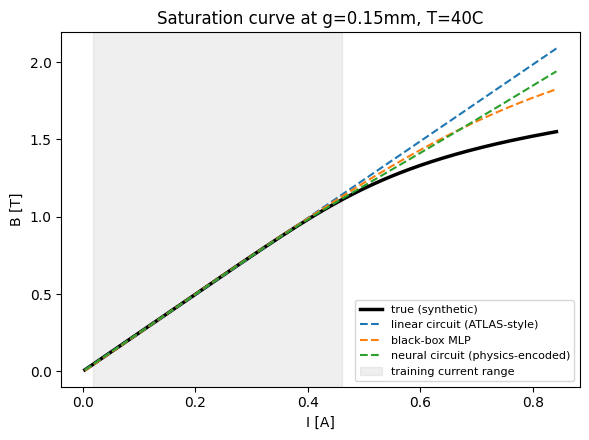

In [4]:
B_range = np.linspace(0.01, 1.55, 200)
g_fixed, T_fixed = 0.15e-3, 40.0
Theta_range = true_theta_from_B(B_range, np.full_like(B_range, g_fixed), np.full_like(B_range, T_fixed))
I_range = Theta_range / N

with torch.no_grad():
    B_lin = solve_B(t(Theta_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed)), linear_model, l_core, n_iter=1).numpy()
    B_mlp_pred = mlp(t(I_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed))).numpy()
    B_nc = solve_B(t(Theta_range), t(np.full_like(B_range, g_fixed)), t(np.full_like(B_range, T_fixed)), neural_circuit, l_core, n_iter=8).numpy()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(I_range, B_range, "k-", linewidth=2.5, label="true (synthetic)")
ax.plot(I_range, B_lin, "--", label="linear circuit (ATLAS-style)")
ax.plot(I_range, B_mlp_pred, "--", label="black-box MLP")
ax.plot(I_range, B_nc, "--", label="neural circuit (physics-encoded)")
ax.axvspan(I_tr.min(), I_tr.max(), color="gray", alpha=0.12, label="training current range")
ax.set_xlabel("I [A]"); ax.set_ylabel("B [T]"); ax.legend(fontsize=8)
ax.set_title(f"Saturation curve at g={g_fixed*1e3:.2f}mm, T={T_fixed:.0f}C")
plt.tight_layout(); plt.show()


## 10. Evaluation

MSE on $B$ [T], train (interpolation) plus the three extrapolation holdouts.

In [5]:
def predict_all(I, g, T):
    Theta = t(I * N)
    with torch.no_grad():
        B_lin = solve_B(Theta, t(g), t(T), linear_model, l_core, n_iter=1).numpy()
        B_mlp = mlp(t(I), t(g), t(T)).numpy()
        B_nc = solve_B(Theta, t(g), t(T), neural_circuit, l_core, n_iter=8).numpy()
    return B_lin, B_mlp, B_nc

rows = []
print(f"{'set':10s} {'linear':>10s} {'MLP':>10s} {'neural circuit':>16s}")
for name, I, g, T, B_true in [
    ("train", I_tr, g_tr, T_tr, B_tr),
    ("extrap I", I_te_I, g_te_I, T_te_I, B_te_I),
    ("extrap g", I_te_g, g_te_g, T_te_g, B_te_g),
    ("extrap T", I_te_T, g_te_T, T_te_T, B_te_T),
]:
    B_lin, B_mlp, B_nc = predict_all(I, g, T)
    mse_lin = float(np.mean((B_lin - B_true) ** 2))
    mse_mlp = float(np.mean((B_mlp - B_true) ** 2))
    mse_nc = float(np.mean((B_nc - B_true) ** 2))
    rows.append((name, mse_lin, mse_mlp, mse_nc))
    print(f"{name:10s} {mse_lin:10.5f} {mse_mlp:10.5f} {mse_nc:16.5f}")


set            linear        MLP   neural circuit
train         0.00003    0.00001          0.00000
extrap I      0.01251    0.00400          0.00326
extrap g      0.00001    0.00187          0.00000
extrap T      0.00029    0.00009          0.00000


## 11. Discussion

Three-way split by extrapolation axis, and it isn't the same winner every time:

- **Extrapolating current (deeper saturation):** the linear circuit is worst by a wide margin — it structurally cannot represent saturation, so pushing current further into the saturating region is exactly where it breaks. The neural circuit wins clearly, having learned the *shape* of saturation from training data that only went partway into it.
- **Extrapolating air gap:** linear and neural-circuit are both essentially exact, and the MLP is not. This has nothing to do with either model's material-permeability term — it's because `R_gap = g/(mu0 A)` is *exact geometry*, encoded identically (and correctly) in both circuit-based models, never learned. The MLP has to learn the g-dependence purely from the training range and pays for it outside that range.
- **Extrapolating temperature:** the neural circuit is again best, with the linear circuit second and the MLP worst.

The neural circuit wins on all three axes here — a cleaner result than Notebook 02's, where the analogous "physics-encoded + learned neural component" model (Jiles-Atherton + residual) badly *lost* on amplitude extrapolation despite winning on temperature extrapolation. The difference is architectural, not incidental: Notebook 02's residual was an **unconstrained additive** correction directly on a derivative (`dM/dH + r_theta(...)`, `r_theta` free to output anything); this notebook's correction is a **bounded multiplicative** modulation (`mu_r0 * (1 + 0.3*tanh(...))`, mathematically incapable of moving permeability more than 30% from its learned base value, regardless of what the network computes for an out-of-distribution input). Embedding a neural network inside a physics-encoded equation does not automatically inherit that equation's extrapolation behavior — but *bounding what the embedded network is allowed to do* is a concrete, checkable design choice that recovers it, at least in this comparison. That is a directly actionable finding for how Method D/I (`PLAN.md` §5) should be built into the eventual combined ATLAS model, not just a one-off observation.

## 12. Relevance for ATLAS

This is closest to a direct, low-risk upgrade path for ATLAS's assumed linear circuit (`PLAN.md` §1): same series topology, same always-exact air-gap term, one bounded learned correction for the one genuinely uncertain quantity (core permeability). The extrapolation results above are a concrete argument for why this is worth doing — the linear model's saturation blind spot is exactly the kind of error a brake operating near its magnetic limits would be most sensitive to.

## 13. Next step

`04_graph_cauer_surface_depth.ipynb` — extend Notebook 01's 1D Cauer ladder into a 2D graph (surface × depth) to add lateral eddy-current redistribution and velocity dependence, the central candidate method for ATLAS per `00_overview_methods.ipynb`.